**Fetch data from Scikit-learn

In [1]:
from sklearn.datasets import fetch_openml
mnist = fetch_openml(
"mnist_784",
version=1,
as_frame=False
)
X = mnist.data
y = mnist.target

In [2]:
#Check the size and basic information
print("Shape:", X.shape)
print("Number of images:", X.shape[0])
print("Number of features:", X.shape[1])
print("Data type:", X.dtype)
print("Minimum pixel value:", X.min())
print("Maximum pixel value:", X.max())

Shape: (70000, 784)
Number of images: 70000
Number of features: 784
Data type: int64
Minimum pixel value: 0
Maximum pixel value: 255


The MNIST dataset contains 70,000 handwritten digit images. Each image has 784 features because each image is 28 × 28 pixels (28 x28=784).
The pixel range is 0 to 255 and it represent the intensity of each pixel in the handwritten image.

In [3]:
#verify teh images present in X
print(X[:5])

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [4]:
print(X[0])

[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   3  18  18  18 126 136 175  26 166 255
 247 127   0   0   0   0   0   0   0   0   0   0   0   0  30  36  94 154
 170 253 253 253 253 253 225 172 253 242 195  64   0   0   0   0   0   0
   0   0   0   0   0  49 238 253 253 253 253 253 253 253 253 251  93  82
  82  56  39   0   0   0   0   0   0   0   0   0   0   0   0  18 219 253
 253 253 253 253 198 182 247 241   0   0   0   0   

In [5]:
#See what is in Y
print(y[:20])

['5' '0' '4' '1' '9' '2' '1' '3' '1' '4' '3' '5' '3' '6' '1' '7' '2' '8'
 '6' '9']


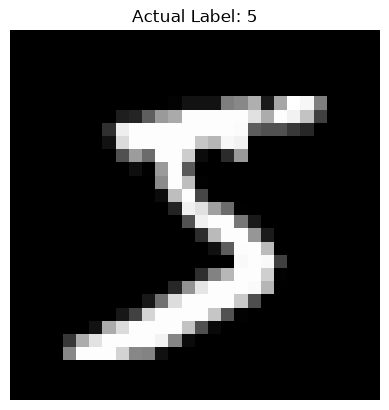

In [6]:
#Display several handwritten digits.
import matplotlib.pyplot as plt

image = X[0].reshape(28, 28)

plt.imshow(image, cmap="gray")
plt.title(f"Actual Label: {y[0]}")
plt.axis("off")
plt.show()

From the analysis
X contains the image pixel values
y contains the actual digit labels

The 70000 digits are hand written. Therefore, the images of the same digit may look different becasue different people have different handwriting styles. The digits can vary in shape, size, thickness, position, and angle even though they represent the same number. This variation makes clustering handwritten digits more challenging.

In [7]:
#Normalize the pixel values by dividing it by 255 since teh original pixel was 0 to 255
X = X / 255.0

We normalize the pixel values to change their range from 0–255 to 0–1. This puts the features on a smaller and consistent scale and makes distance calculations used by K-Means more numerically manageable. Since K-Means groups observations based on distances, normalized values are convenient for the clustering process.

**Part 2 — Discover Groups Using K-Means**


In [9]:
#2.1 Use a manageable sample
import numpy as np
rng = np.random.RandomState(42)
sample_indices = rng.choice(
len(X),
size=10000,
replace=False
)
X_sample = X[sample_indices]
y_sample = y[sample_indices]

In [10]:
#print 
print("X sample shape:", X_sample.shape)
print("y sample shape:", y_sample.shape)

X sample shape: (10000, 784)
y sample shape: (10000,)


X_sample contains the 10,000 images that K-Means will cluster. y_sample contains their true digit labels that will be used to evaluate the k-means

In [25]:
#use teh elbow method to compare K = 5, K = 10 and K = 15
from sklearn.cluster import KMeans

k_values = [5, 10, 15]
inertias = []

for k in k_values:
    
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    # Train the model
    kmeans.fit(X_sample)
    
    # Add the inertia to the list
    inertias.append(kmeans.inertia_)
    
    print(f"K = {k}, Inertia = {kmeans.inertia_:.2f}")

print("Inertias:", inertias)

K = 5, Inertia = 432527.75
K = 10, Inertia = 390343.06
K = 15, Inertia = 365525.23
Inertias: [432527.7509384551, 390343.06280820165, 365525.23250646563]


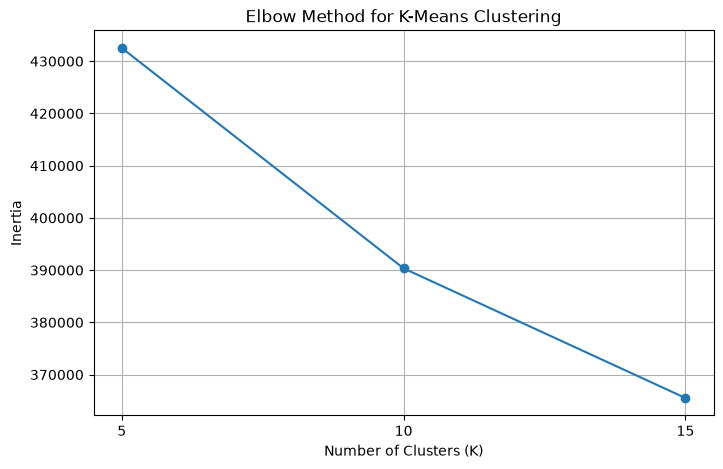

In [26]:
#Create a line chart showing k on the axis
# Plot the elbow curve
plt.figure(figsize=(8, 5))

plt.plot(k_values, inertias, marker='o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for K-Means Clustering")
plt.xticks(k_values)
plt.grid()

plt.show()

**Train the final K-Means model**

In [27]:
kmeans = KMeans(
n_clusters=10,
random_state=42,
n_init=10
)
clusters = kmeans.fit_predict(X_sample)

In [28]:
#Check the cluster sizes
import pandas as pd
pd.Series(clusters).value_counts().sort_index()

0     519
1     757
2    1487
3    1039
4    1475
5    1331
6     513
7     906
8    1017
9     956
Name: count, dtype: int64

I choose the point where the elbow begin to bend, that is K = 10. This is because the inertia decreased significantly from K = 5 to K = 10, from 432,527.75 to 390,343.06. but from K = 10 to K = 15, the decrease was smaller. At this point the number of e=images are as above

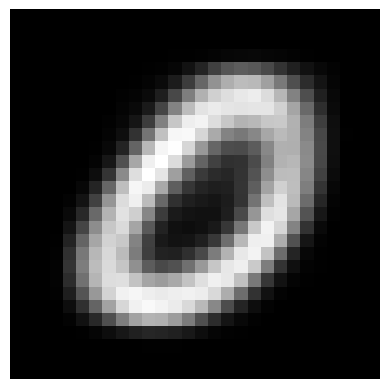

In [29]:
#Display the cluster centroids
centroids = kmeans.cluster_centers_
plt.imshow(
centroids[0].reshape(28, 28),
cmap="gray"
)
plt.axis("off")
plt.show()

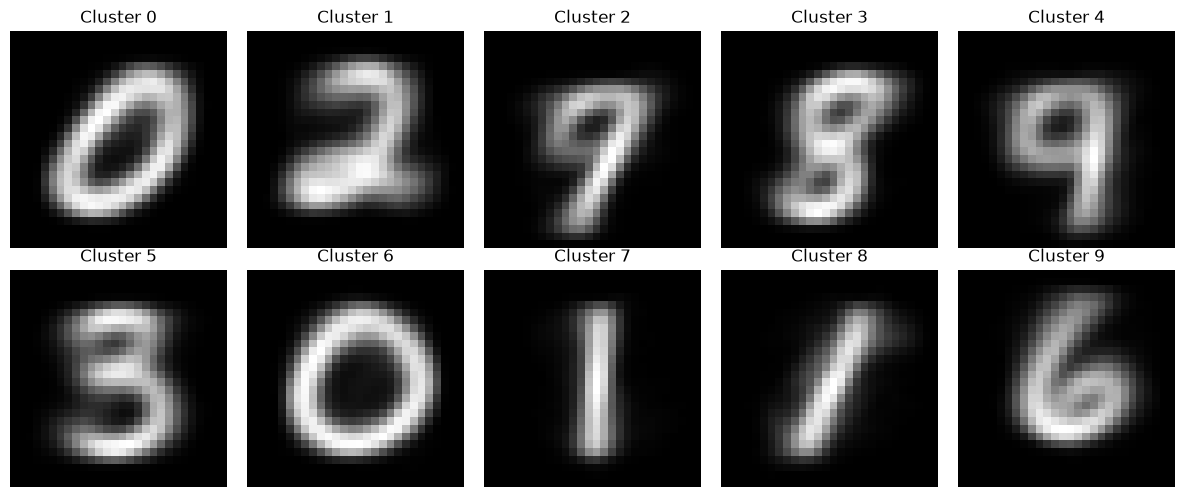

In [30]:
#Display the centroids for all clusters
centroids = kmeans.cluster_centers_

plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(centroids[i].reshape(28, 28), cmap="gray")
    plt.title(f"Cluster {i}")
    plt.axis("off")

plt.tight_layout()
plt.show()

Cluster 0 actually look like 0 cluster 1 looks like 2, cluster 2 looks like 9 c;luster 7 and 8 looks like 1 in different hand writing. all the clusters excent  cluster 5 are easily recognizable

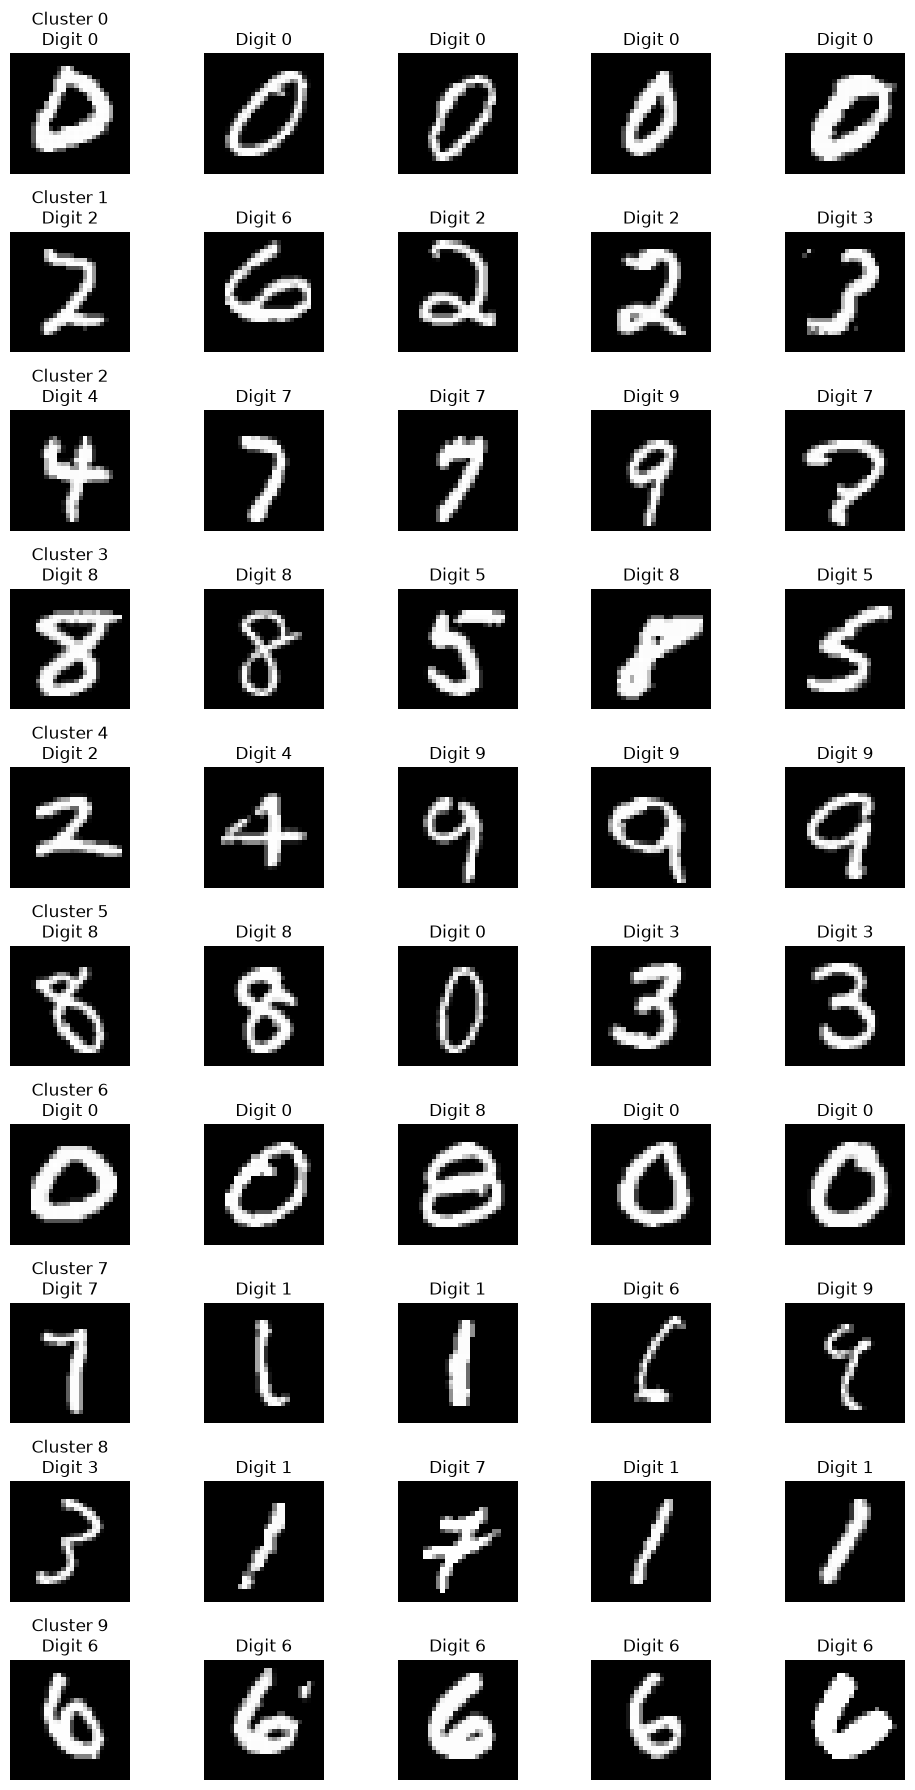

In [33]:
#Select a few images from each cluster and display them.
# Display 5 images from each cluster
cluster_labels = kmeans.labels_

num_images = 5

plt.figure(figsize=(10, 18))

for cluster in range(10):

    # Find images belonging to this cluster
    cluster_indices = np.where(cluster_labels == cluster)[0]

    # Select the first 5
    selected_indices = cluster_indices[:num_images]

    for j, index in enumerate(selected_indices):
        plt.subplot(10, num_images, cluster * num_images + j + 1)

        plt.imshow(
            X_sample[index].reshape(28, 28),
            cmap="gray"
        )

        plt.axis("off")

        if j == 0:
            plt.title(
                f"Cluster {cluster}\nDigit {y_sample[index]}"
            )
        else:
            plt.title(
                f"Digit {y_sample[index]}"
            )

plt.tight_layout()
plt.show()

Do images within the same cluster look similar?
Not all the clusters shows thesame images. Forexample; cluster 0 shows all 0 in different handwriting , cluster 9 shows 6 in different hand writing and cluster 1, 2, 3, 4, 5, 6 ,7  and 8 all have different digits

**Part 4 — Compare Clusters with the Actual Digit Labels**

In [34]:
pd.crosstab(
clusters,
y_sample
)

col_0,0,1,2,3,4,5,6,7,8,9
row_0,,,,,,,,,,
0,427,0,11,17,0,39,14,1,7,3
1,5,1,666,42,8,4,10,9,12,0
2,4,1,8,7,290,57,1,654,23,442
3,22,2,20,146,4,266,9,1,560,9
4,3,4,26,33,500,63,14,295,34,503
5,31,5,71,700,0,310,4,0,197,13
6,458,0,5,2,2,5,26,2,6,7
7,0,642,45,55,16,18,34,34,32,30
8,2,497,70,24,49,155,48,57,87,28


using the y-sample. K-Means discovered the following:
Cluster 0 and 6 both shows mostly 0 while cluster 7 and 8 mostly shows 1. Cluster 9 has mostly 6 just like the images above. Therefore, K-mean was able to create multiple clusters from different writing styles of thesame digits. Some of the handwriten images have similar pixel and are easily identifable while others are very diffecult to identify.

What digits are most common in Cluster 3? 8

Does each cluster mainly contain one digit? No, Cluster 9 contains mostly digit 6, Cluster 1 mostly digit 2, and Cluster 5 mostly digit 3. However Cluster 4 contains many 9, 4, and 7

Which digits are grouped together? 0, 1 an d6 in clusters 0,6,7 and 9 respectively

Which digits appear in multiple clusters?  many 9 in cluster 2,and 4, many 8s in cluster 3, and 5.

Why might some digits be difficult to separate? because of different handwritten styles. that makes it difficult for K mean to separate

**Part 5 — Visualize the Clusters with PCA**

In [35]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_sample)

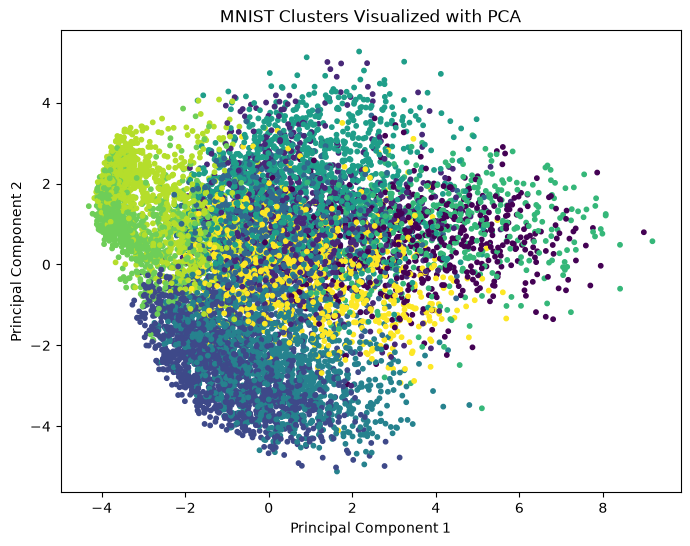

In [36]:
#Create a scatter plot using PC1 on the x-axis, PC2 on the y-axis and K-Means cluster as the color
plt.figure(figsize=(8, 6))
plt.scatter(
X_pca[:, 0],
    X_pca[:, 1],
c=clusters,
s=10
)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("MNIST Clusters Visualized with PCA")
plt.show()

Do the clusters appear separated?. No some clusters occupy recognizable regions of the PCA plot, while others are mixed together

Are some clusters overlapping? Yes. There is considerable overlap, especially around the centre of the plot

Which groups appear to be more clearly separated? The outer far left region. the rest are overlapping

Does the PCA visualization support what you observed from the cluster images?

**Part 6 — Predict the Cluster of New Images**

In [38]:
# Find indices that were NOT used for K-Means training to avoid data leaking
all_indices = np.arange(len(X))
unused_indices = np.setdiff1d(all_indices, sample_indices)

# Select the first 10 unseen images
new_indices = unused_indices[:10]

X_new = X[new_indices]
y_new = y[new_indices]

print("X_new shape:", X_new.shape)
print("Actual digits:", y_new)

X_new shape: (10, 784)
Actual digits: ['5' '0' '4' '1' '2' '1' '3' '1' '4' '3']


In [40]:
#predict teh cluster
new_clusters = kmeans.predict(X_new)

print("Predicted clusters:", new_clusters)

Predicted clusters: [3 0 4 8 1 7 3 7 2 5]


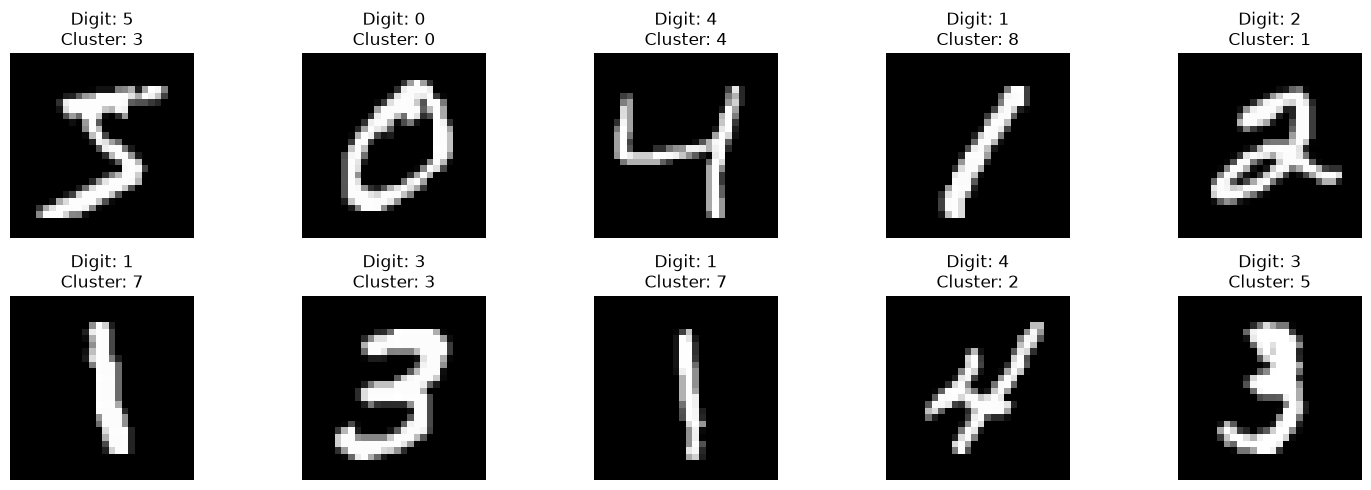

In [41]:
#Display the images and predicted clusters
plt.figure(figsize=(15, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)

    plt.imshow(
        X_new[i].reshape(28, 28),
        cmap="gray"
    )

    plt.title(
        f"Digit: {y_new[i]}\nCluster: {new_clusters[i]}"
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

The Digit is the true MNIST label. 
The Cluster is what your trained K-Means model assigned.

In [42]:
#Which cluster was assigned to each image?

for i in range(10):
    print(
        f"Image {i + 1}: "
        f"Actual digit = {y_new[i]}, "
        f"Predicted cluster = {new_clusters[i]}"
    )

Image 1: Actual digit = 5, Predicted cluster = 3
Image 2: Actual digit = 0, Predicted cluster = 0
Image 3: Actual digit = 4, Predicted cluster = 4
Image 4: Actual digit = 1, Predicted cluster = 8
Image 5: Actual digit = 2, Predicted cluster = 1
Image 6: Actual digit = 1, Predicted cluster = 7
Image 7: Actual digit = 3, Predicted cluster = 3
Image 8: Actual digit = 1, Predicted cluster = 7
Image 9: Actual digit = 4, Predicted cluster = 2
Image 10: Actual digit = 3, Predicted cluster = 5


The model was able to correctly predict digit 0, 4 and 3 for images 2 , 3 and 7. But the rest of the images, the model was able to predict the actual

Do images that look similar receive similar cluster assignments?
some of the cluster have similar assignment like cluster 0 = 0
cluster 4= 4
cluster 3= 3

Are any assignments surprising?
Yes. Cluster 3 had mostly 8 and 5s, but the predicted 5. 
Also cluster 2 mostly 7 but the model predicted it is 4

Why might K-Means sometimes assign an image to an unexpected cluster?
K-Means assigns each new image to the cluster with the nearest centroid based on pixel values. Different digits can have similar shapes, and the same digit can be written in many different styles. Therefore, an image may sometimes be closer to the centroid of a cluster associated mostly with another digit. 

K-Mean limitation
K-Means groups images based on distance between their pixel values rather than understanding what the digits mean. Different writing styles can cause the same digit to be placed into different clusters, while visually similar digits can be grouped together. K-Means also requires the number of clusters to be selected beforehand and tends to work best when clusters are reasonably compact. Handwritten digits can have complex shapes and variations that do not naturally form simple clusters.

How this is different from Project 3 supervised learning 
This project uses unsupervised learning, meaning K-Means was given the image features (X) but not the actual digit labels (y) during training. Its purpose was to discover patterns and groups on its own. The actual labels were only used afterward to evaluate and interpret the clusters.
In Project 3, supervised learning models were trained using both the features and known target labels. The models learned the relationship between the inputs and the correct answers so they could predict a specific target with the unseen test data. Therefore, supervised learning tries to predict known outcomes, while this K-Means project tries to discover hidden groups or patterns without being given the answers.
